In [1]:
#Step 1: Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
from sklearn import svm
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, f1_score, classification_report

In [5]:
#Step 2: Data Importing &data Analysis

In [6]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv.xls")

In [7]:
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [8]:
data_df.info

<bound method DataFrame.info of       age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    75.0        0                       582         0                 20   
1    55.0        0                      7861         0                 38   
2    65.0        0                       146         0                 20   
3    50.0        1                       111         0                 20   
4    65.0        1                       160         1                 20   
..    ...      ...                       ...       ...                ...   
294  62.0        0                        61         1                 38   
295  55.0        0                      1820         0                 38   
296  45.0        0                      2060         1                 60   
297  45.0        0                      2413         0                 38   
298  50.0        0                       196         0                 45   

     high_blood_pressure  platelets  serum_

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/1031362883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data_df["DEATH_EVENT"], palette=cols)


[Text(0, 0, '203')]

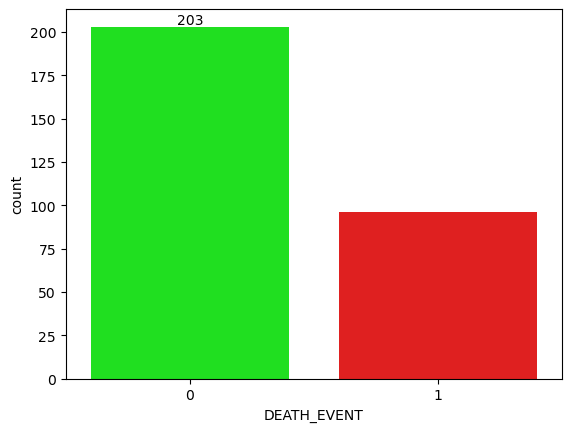

In [9]:
cols = ["#00FF00","#FF0000"]
ax = sns.countplot(x=data_df["DEATH_EVENT"], palette=cols)
ax.bar_label(ax.containers[0])  

In [10]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


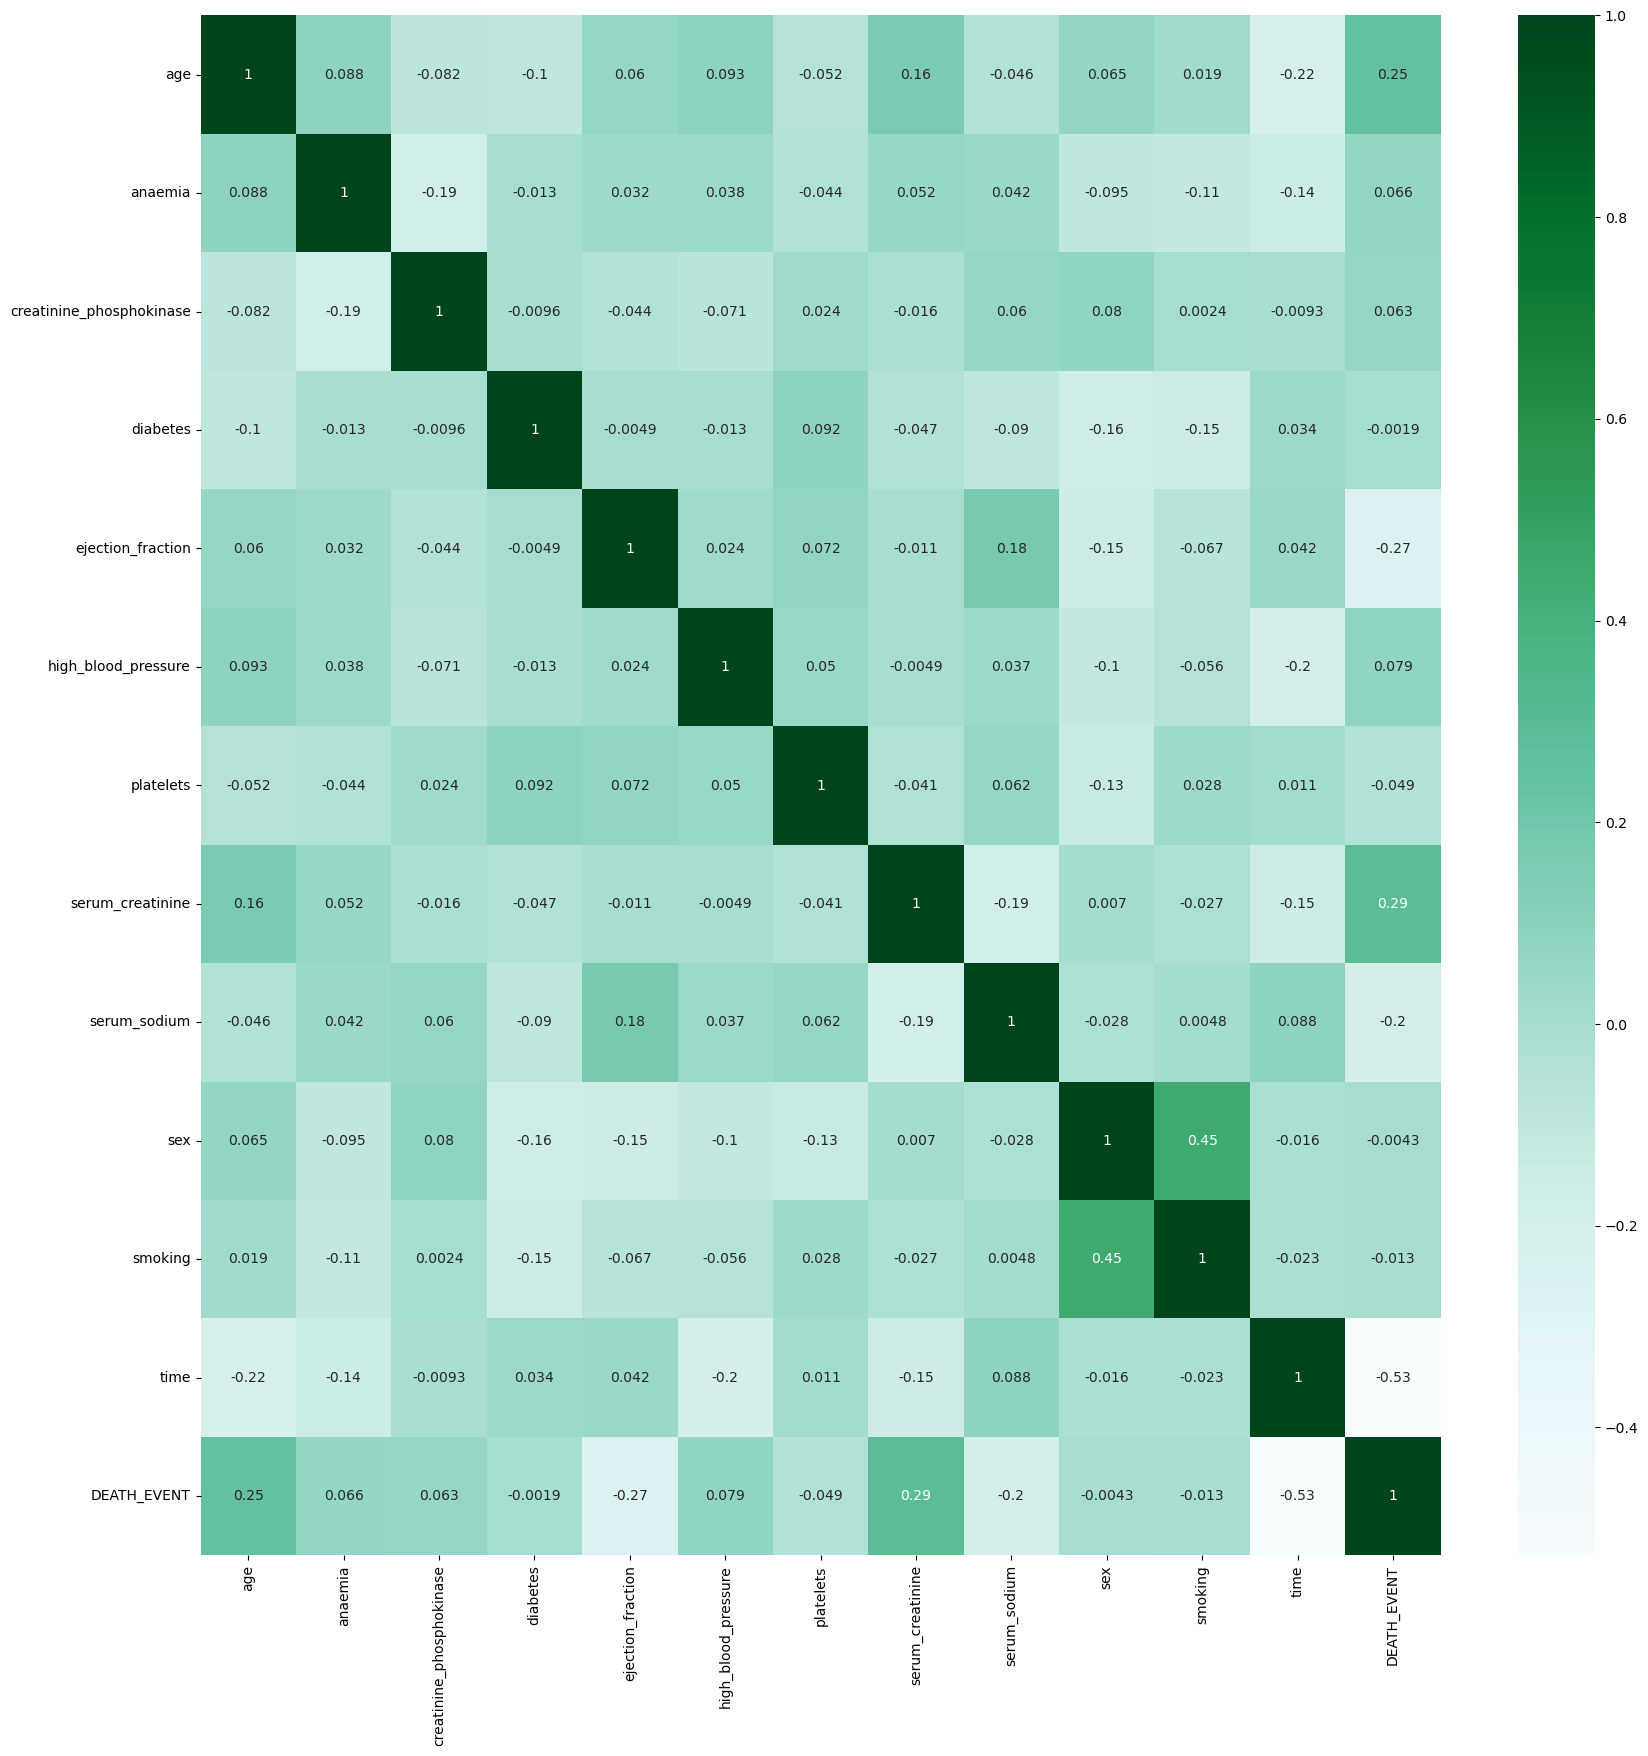

In [11]:
plt.figure(figsize=(20, 20))
plt.subplot(1, 1, 1)  
sns.heatmap(data_df.corr(), cmap="BuGn", annot=True)
plt.show()

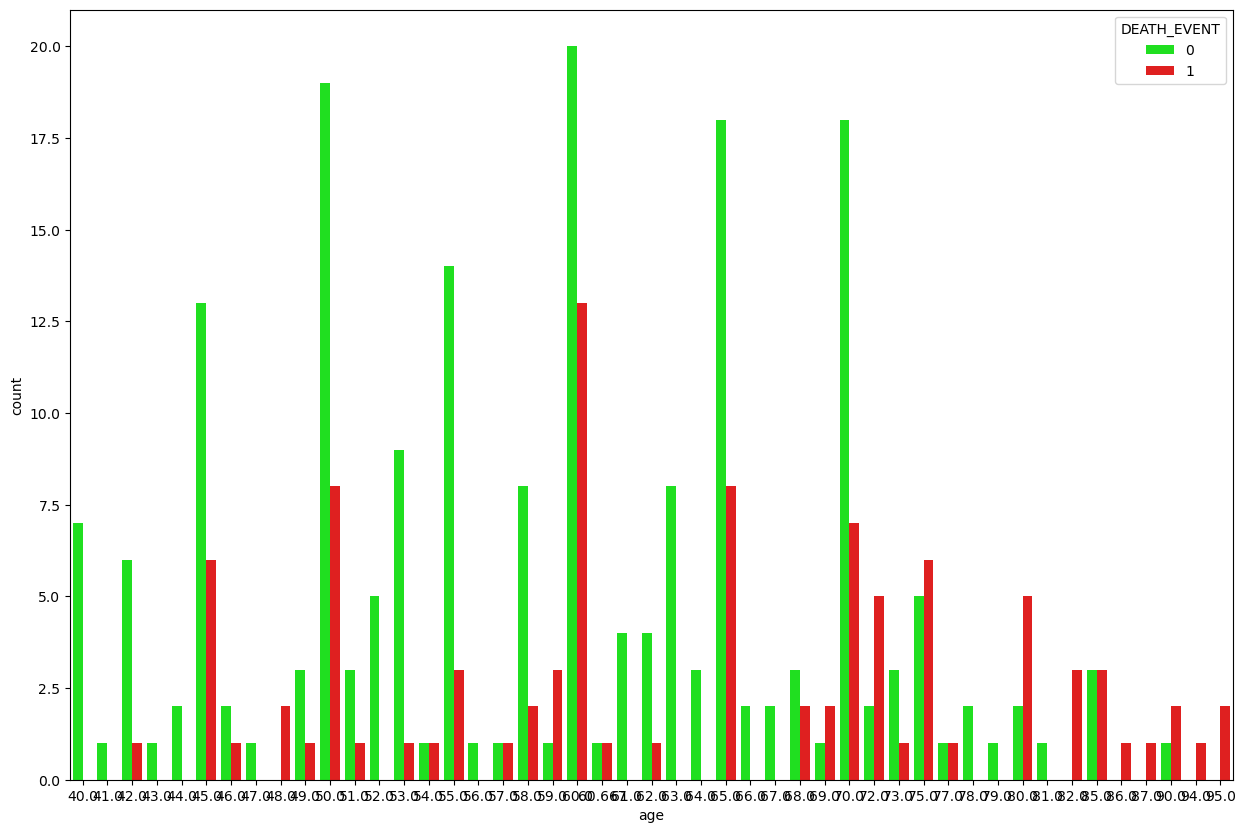

In [12]:
plt.figure(figsize=(15,10))
days_of_week = sns.countplot(x=data_df['age'], data=data_df, hue="DEATH_EVENT", palette = cols)

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


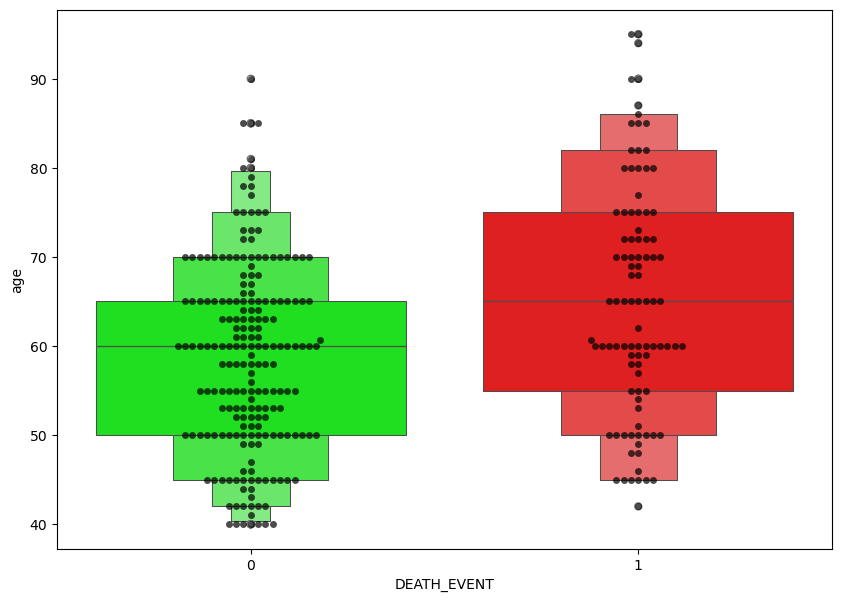

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


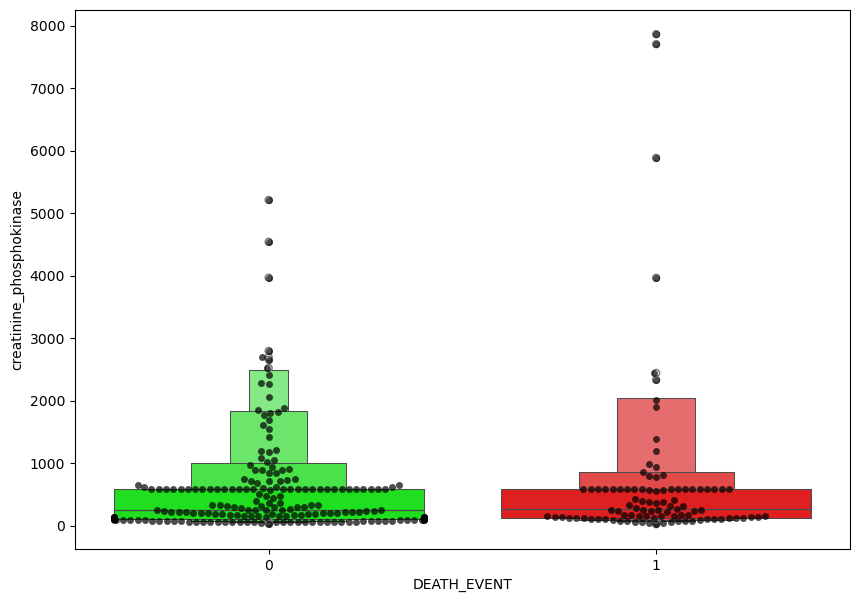

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


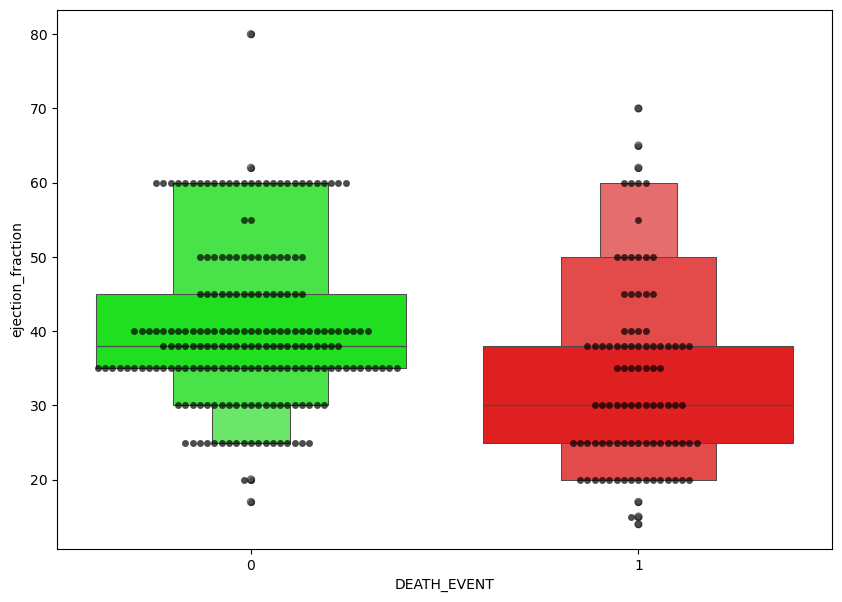

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


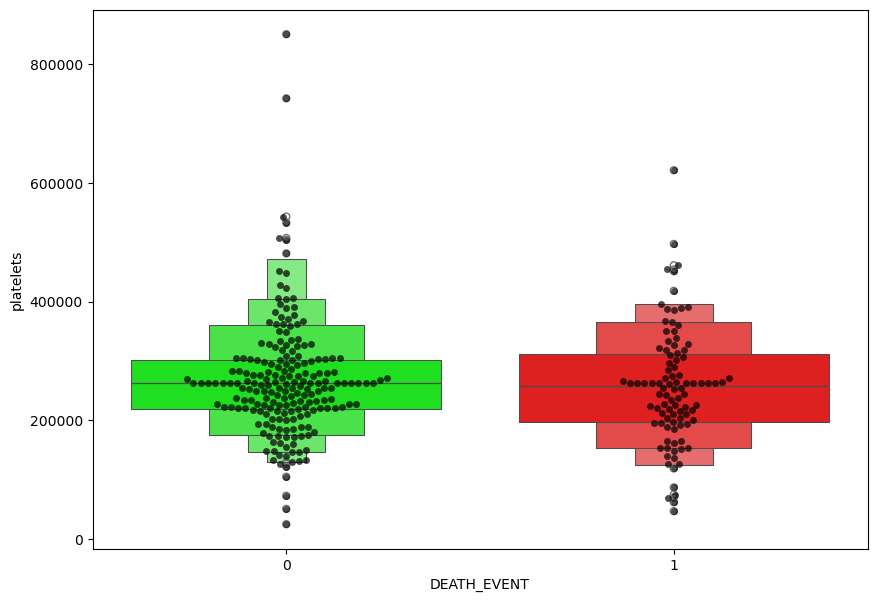

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


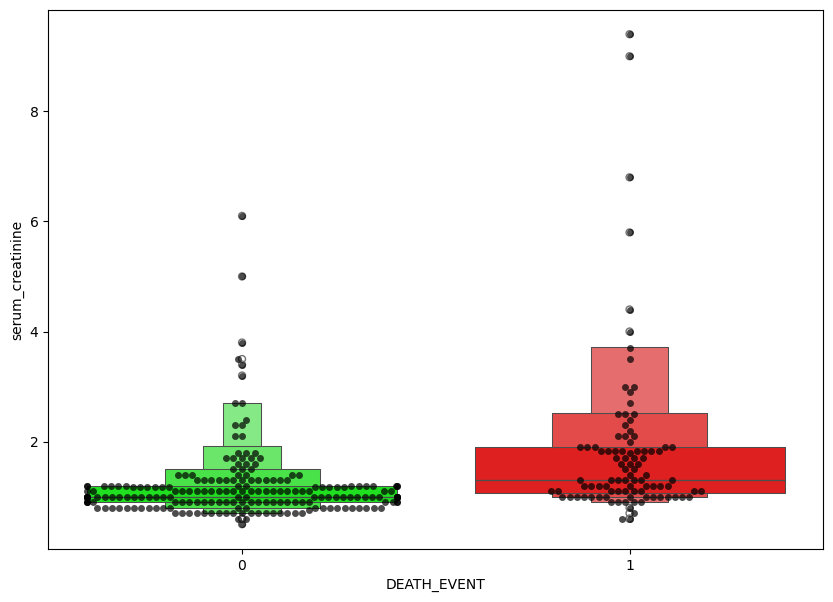

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


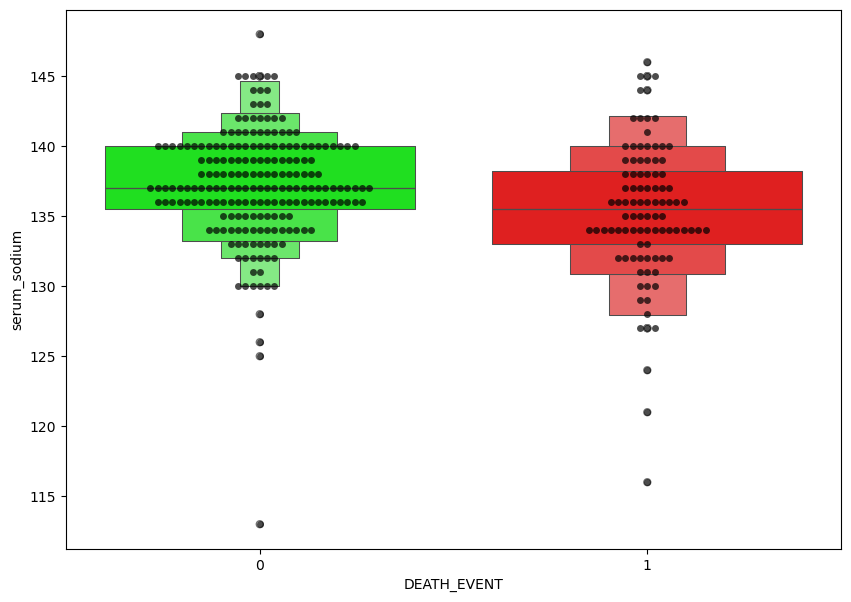

/var/folders/1c/2bqbcmjd513gs937s0flzs3m0000gn/T/ipykernel_1390/3168132928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


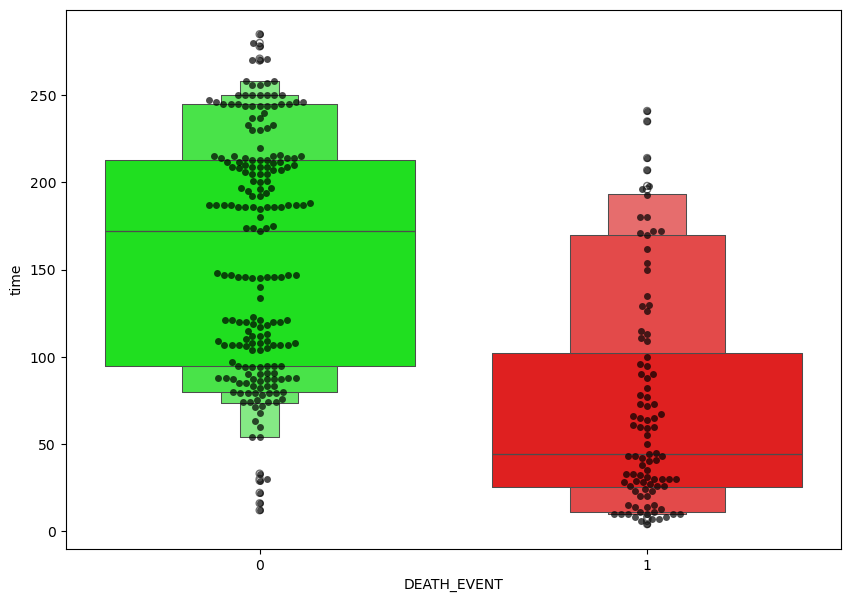

In [13]:
feature = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium", "time"]
for i in feature:
    plt.figure(figsize=(10,7))
    sns.swarmplot(x=data_df["DEATH_EVENT"], y=data_df[i], color = "black", alpha = 0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
    plt.show()

In [14]:
#Step 3 : Data Preprocessing

In [15]:
x = data_df.drop(["DEATH_EVENT"], axis =1)
y = data_df["DEATH_EVENT"]

In [16]:
X = pd.read_csv("heart_failure_clinical_records_dataset.csv.xls")
col_name = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_name)

In [17]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


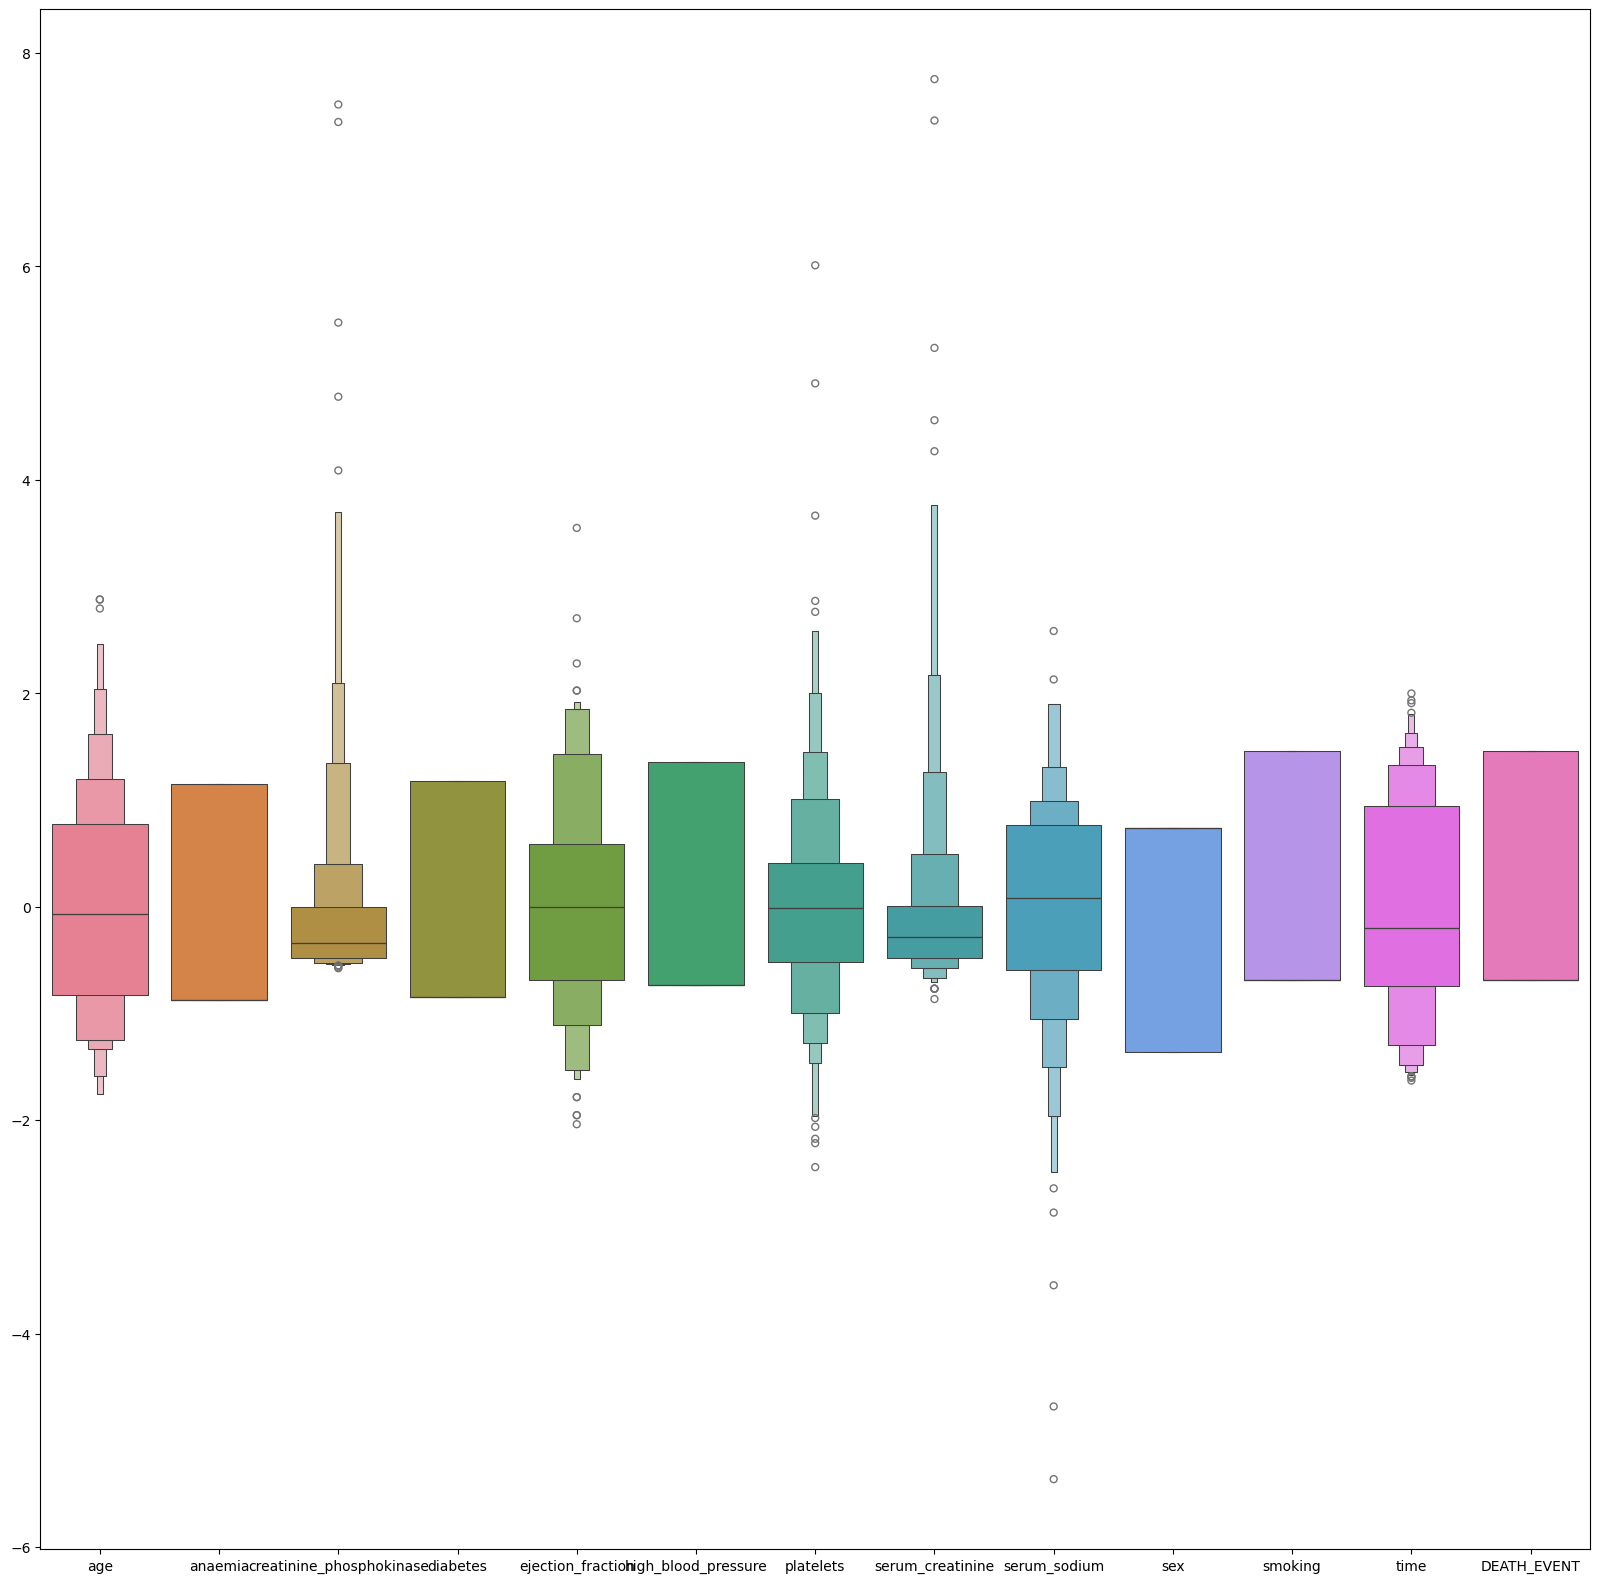

In [18]:
plt.figure(figsize=(20,20))
sns.boxenplot(data=X_scaled)
plt.show()

In [19]:
X_train, X_tests, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

In [20]:
#Step 4: Model Building

In [21]:
#1. SVM

In [22]:
model1 = svm.SVC()

In [23]:
model1.fit(X_train, y_train)

SVC()

In [24]:
y_pred = model1.predict(X_tests)

In [25]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0])

In [26]:
y_test

272    0
267    0
57     0
180    0
264    0
      ..
271    0
30     1
27     1
13     1
198    0
Name: DEATH_EVENT, Length: 90, dtype: int64

In [27]:
y_train

211    0
80     0
50     1
19     1
170    0
      ..
241    0
289    0
100    0
14     0
42     1
Name: DEATH_EVENT, Length: 209, dtype: int64

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        63
           1       1.00      0.96      0.98        27

    accuracy                           0.99        90
   macro avg       0.99      0.98      0.99        90
weighted avg       0.99      0.99      0.99        90



In [29]:
#2. ANN

In [30]:
!pip install tensorflow

In [ ]:
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001, patience = 20, restore_best_weights = True)
model = Sequential()
model.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation='sigmoid'))

In [4]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy']) 

NameError: name 'model' is not defined

In [2]:
model.summary()

NameError: name 'model' is not defined

In [3]:
history = model.fit(X_train, y_train, batch_size=25, epochs = 100, callbacks=[early_stopping], validation_split=0.25)

NameError: name 'model' is not defined

In [6]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['loss']], label="Training loss")
plt.plot(history_df.loc[:, ['val_loss']], label="Validation loss")
plt.legend()
plt.show()

NameError: name 'pd' is not defined

In [7]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], label="Training accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']], label="Validation accuracy")
plt.legend()
plt.show()

NameError: name 'pd' is not defined

In [8]:
y_pred = model.predict(X_tests)

NameError: name 'model' is not defined

In [10]:
y_pred = (y_pred>0.5)

NameError: name 'y_pred' is not defined

In [11]:
print(classification_report(y_test, y_pred))

NameError: name 'classification_report' is not defined